## QUASI-STATITC SPRING SLIDER

### INTEGRATION

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from tqdm import tqdm

In [6]:
## CONSTANTS

beta_1 = 1
beta_2 = 0.84
rho = 0.048

kappa_prime = 0.8544
kappa_cr_1 = beta_1 - 1
kappa_cr_2 = (
    kappa_cr_1 + rho*(2*beta_1 + (beta_2-1)*(2+rho)) + np.sqrt(
        4*rho**2 * (kappa_cr_1+beta_2) + (kappa_cr_1 + rho**2 * (beta_2-1))**2
    )
) / (2*(1+rho))

kappa = kappa_cr_2 * kappa_prime
## define EOMS
print(kappa)
v_0 = 1

def func(input_vars):
    x, y, z = input_vars

    ex = np.exp(x)

    fx = -kappa * (ex - v_0)
    + ex * (x*(beta_1-1) + y - z)
    + rho * ex * (beta_2*x + z)
    
    fy = -kappa * (ex-v_0)

    fz = -rho*ex*(beta_2*x+z)

    return [fx, fy, fz]

def t_func(t, input_vars):
    
    return func(input_vars)

0.06858744329064924


In [10]:
## solve ivp

t_start = 0
t_end = 10000
dt = 0.1

t_eval = np.arange(t_start, t_end+0.1, dt)

x_0 = (0.05, 0, 0)

soln = solve_ivp(t_func, (t_start, t_end), x_0, t_eval=t_eval)

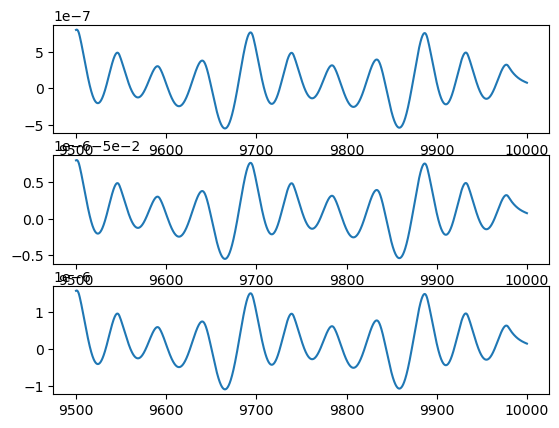

In [11]:
num_pts = 5000

t = soln.t[-num_pts:]
x, y, z = soln.y[:,-num_pts:]

fig, axs = plt.subplots(3, 1)
axs = axs.flatten()

axs[0].plot(t, x)
axs[1].plot(t, y)
axs[2].plot(t, z)

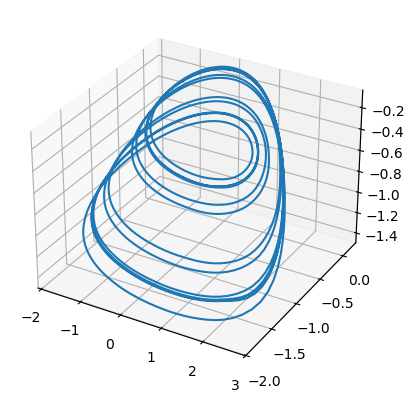

In [12]:
fig, ax = plt.subplots(subplot_kw={'projection':'3d'})

ax.plot(x, y, z)

### LYAPUNOV SPECTRUM AND KAPLAN-YORKE DIMENSION

In [13]:
t

array([ 9500.1,  9500.2,  9500.3, ...,  9999.8,  9999.9, 10000. ],
      shape=(5000,))

In [14]:
## alternate jacobian from lectures potentially instead?
#from scipy.differentiate import jacobian

## manual implementation
def jacobian(input_vars, kappa=kappa, beta_1=beta_1, beta_2=beta_2, rho=rho):

    assert len(input_vars) == 3

    x, y, z = input_vars

    ex = np.exp(x)
    ez = np.exp(z)

    J11 = -kappa * ex + ex * (
        x*(beta_1 - 1) + y - z + beta_1 - 1
    ) + rho * ex * (beta_2 * x + z + beta_2)
    J12 = ex
    J13 = ex * (-1 + rho)

    J21 = -kappa * ex
    J22 = 0
    J23 = 0

    J31 = -rho * ex * beta_2 * (x + 1)
    J32 = 0
    J33 = -rho * ex


    jac = np.array([
        [J11, J12, J13],
        [J21, J22, J23],
        [J31, J32, J33]
    ])

    return jac

In [15]:
R_diagonals = []

I = np.eye(3)

V_prime = I.copy()

for t_id in tqdm(range(len(soln.t))):
    try:
        ## when using scipy
        jac = jacobian(func, soln.y[:,t_id]).df

    except:
        ## when using manual implementation
        jac = jacobian(soln.y[:, t_id])

    A = I + jac * dt

    V = A @ V_prime

    qr_V = np.linalg.qr(V)

    new_V = qr_V.Q
    new_R = qr_V.R

    R_diag = np.log(np.abs(new_R.diagonal()))

    R_diagonals.append(R_diag / dt)

    V_prime = new_V

R_diagonals = np.array(R_diagonals)


100%|██████████| 100001/100001 [00:02<00:00, 37399.19it/s]


In [ ]:
with open('R_diagonals.txt', 'w') as out_file:

    out_file.write(repr(
        list(
            [float(j) for j in i] for i in R_diagonals
        )
    ))

In [ ]:
import json

with open('R_diagonals.txt', 'r') as diagonals_file:

    R_diagonals = json.loads(diagonals_file.read())

In [33]:
pd.Series(diag_df.index)

0              0
1              1
2              2
3              3
4              4
           ...  
99996      99996
99997      99997
99998      99998
99999      99999
100000    100000
Length: 100001, dtype: int64

<Axes: >

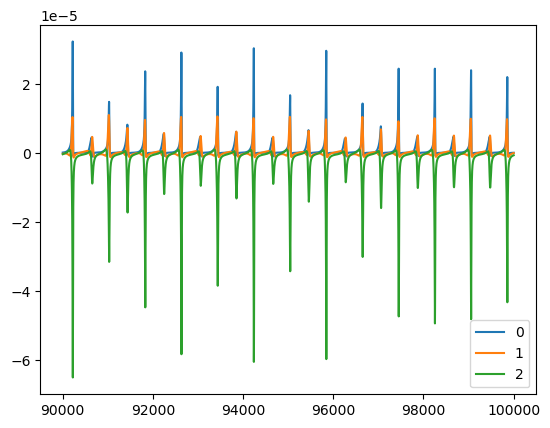

In [53]:
cum_le = (R_diagonals.T / (range(1,100002))).T

le_df = pd.DataFrame(cum_le)

le_df[90000:].plot()

<Axes: >

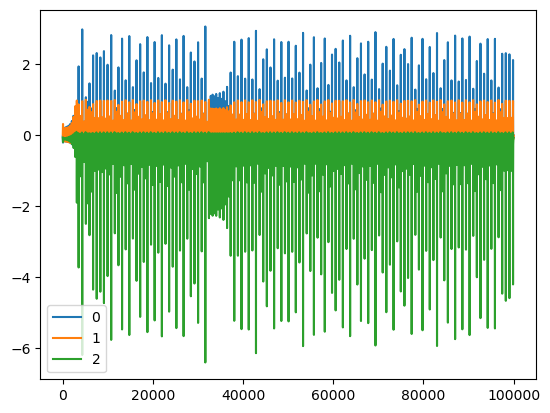

In [16]:
import pandas as pd

diag_df = pd.DataFrame(R_diagonals)

rolling_mean = diag_df.rolling(window=5).mean()

s1 = rolling_mean[0] + rolling_mean[1]
s2 = rolling_mean[0] + rolling_mean[1] + rolling_mean[2]

#plt.plot(s1)
#plt.plot(s2)

rolling_mean.plot()

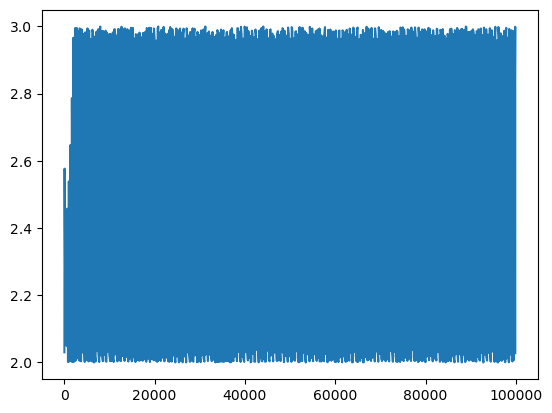

In [17]:
diff_sum_0 = diag_df[0] + diag_df[1]
diff_sum_1 = diag_df[0] + diag_df[1] + diag_df[2]

mask_0 = diff_sum_0 >= 0
mask_1 = diff_sum_1 < 0

ky_mask = mask_0 & mask_1

valid_ky = diag_df[ky_mask]

ly_dim = 2 + (valid_ky[0]+valid_ky[1])/np.abs(valid_ky[2])

plt.plot(ly_dim)

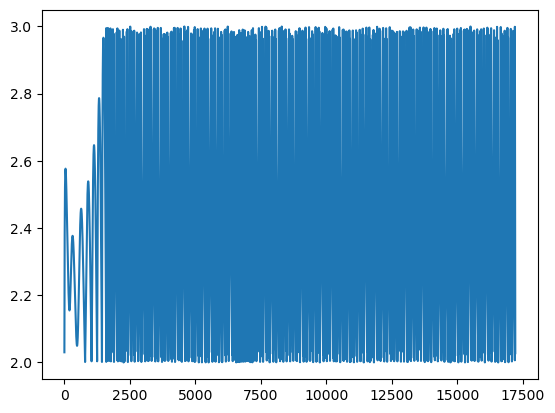

In [18]:
diff_sum_0 = R_diagonals[:, 0] + R_diagonals[:, 1]
diff_sum_1 = R_diagonals[:, 0] + R_diagonals[:, 1] + R_diagonals[:,2]

mask_0 = diff_sum_0 >= 0
mask_1 = diff_sum_1 < 0

ky_mask = mask_0 & mask_1

valid_ky = R_diagonals[ky_mask]

ly_dim = 2 + (valid_ky[:,0]+valid_ky[:,1])/np.abs(valid_ky[:,2])

plt.plot(ly_dim)